# MultiBranchMLP с PyTorch Lightning

В этом ноутбуке реализована улучшенная модель **MultiBranchMLP** для
классификации несбалансированных данных, использующая библиотеку
[PyTorch Lightning](https://www.pytorchlightning.ai/).

## Основные компоненты

- **LightningDataModule** для генерации синтетического датасета с дисбалансом
  и формирования загрузчиков с oversampling (WeightedRandomSampler).
- **LightningModule** для определения модели, функции потерь, шагов обучения
  и валидации, конфигурации оптимизатора и scheduler.
- **Гиперпараметрический поиск**: демонстрация кода для перебора скрытой
  размерности, числа блоков и скорости обучения.
- **Ансамблирование**: обучение нескольких моделей и усреднение их
  предсказаний.

> **Примечание:** запуск этого ноутбука требует установленных PyTorch и
> PyTorch Lightning.  Код предоставлен в виде примеров,
> которые вы можете адаптировать и выполнить в своей среде.

In [30]:
# Импортируем библиотеки
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import random
import numpy as np
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Настройка воспроизводимости
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
import sys
print(sys.executable)
num_workers=11

C:\Users\ART PRONKIN\AppData\Local\Programs\Python\Python313\python.exe


In [31]:
# LightningDataModule для синтетического дисбалансированного датасета
class SyntheticWineDataModule(pl.LightningDataModule):
    def __init__(self, n_samples=2000, n_features=11, n_classes=6,
                 batch_size=128, val_split=0.2, class_weights=None,
                 random_state=42):
        super().__init__()
        self.n_samples = n_samples
        self.n_features = n_features
        self.n_classes = n_classes
        self.batch_size = batch_size
        self.val_split = val_split
        self.random_state = random_state
        if class_weights is None:
            # Дисбаланс между классами по умолчанию
            self.class_weights = [0.05, 0.1, 0.3, 0.35, 0.15, 0.05]
        else:
            self.class_weights = class_weights
        self.train_dataset = None
        self.val_dataset = None
        self.full_labels = None

    def prepare_data(self):
        # Нет внешних данных — ничего загружать не нужно
        pass

    def setup(self, stage: str = None):
        # Генерируем синтетические данные с заданным дисбалансом
        X, y = make_classification(
            n_samples=self.n_samples,
            n_features=self.n_features,
            n_informative=self.n_features,
            n_redundant=0,
            n_classes=self.n_classes,
            n_clusters_per_class=1,
            weights=self.class_weights,
            flip_y=0.01,
            class_sep=1.0,
            random_state=self.random_state
        )
        X = X.astype(np.float32)
        y = y.astype(np.int64)
        self.full_labels = y
        # Разбиваем на train/val
        num_train = int(len(X) * (1.0 - self.val_split))
        train_indices = np.arange(num_train)
        val_indices = np.arange(num_train, len(X))
        tensor_dataset = torch.utils.data.TensorDataset(torch.tensor(X), torch.tensor(y))
        self.train_dataset = torch.utils.data.Subset(tensor_dataset, train_indices)
        self.val_dataset = torch.utils.data.Subset(tensor_dataset, val_indices)

    def _create_sampler(self):
        # Вычисляем веса для oversampling
        y_train = self.full_labels[: len(self.train_dataset)]
        class_counts = np.bincount(y_train, minlength=self.n_classes).astype(float)
        sample_weights = 1.0 / class_counts[y_train]
        sample_weights = torch.tensor(sample_weights, dtype=torch.float32)
        return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    def train_dataloader(self):
        sampler = self._create_sampler()
        return DataLoader(self.train_dataset, batch_size=self.batch_size, sampler=sampler,num_workers=num_workers, persistent_workers= True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False,num_workers=num_workers, persistent_workers= True)

    @property
    def input_dim(self):
        return self.n_features

    @property
    def num_classes(self):
        return self.n_classes


Распределение по классам:
  Класс 0: 102 экземпляров
  Класс 1: 200 экземпляров
  Класс 2: 600 экземпляров
  Класс 3: 695 экземпляров
  Класс 4: 300 экземпляров
  Класс 5: 103 экземпляров


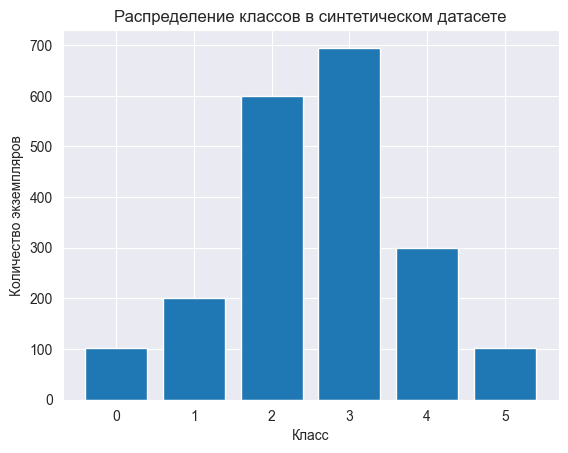

In [32]:
# Визуализируем распределение классов
set_seed(42)
dm = SyntheticWineDataModule()
dm.prepare_data()
dm.setup()
labels = dm.full_labels
unique, counts = np.unique(labels, return_counts=True)
print('Распределение по классам:')
for u, c in zip(unique, counts):
    print(f'  Класс {u}: {c} экземпляров')
plt.figure()
plt.bar(unique, counts)
plt.xlabel('Класс')
plt.ylabel('Количество экземпляров')
plt.title('Распределение классов в синтетическом датасете')
plt.show()


In [33]:
# Рассчитываем веса классов для взвешенной кросс‑энтропии
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print('Веса классов:', class_weights_tensor.numpy())


Веса классов: [3.267974  1.6666666 0.5555556 0.4796163 1.1111112 3.2362459]


In [34]:
# Определяем блоки MLP и LightningModule
class BottleneckBlock(nn.Module):
    def __init__(self, dim, bottleneck_ratio=0.25, dropout=0.2):
        super().__init__()
        hidden_dim = int(dim * bottleneck_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

class InvertedBottleneckBlock(nn.Module):
    def __init__(self, dim, expansion_ratio=4.0, dropout=0.2):
        super().__init__()
        hidden_dim = int(dim * expansion_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

class RegularBlock(nn.Module):
    def __init__(self, dim, hidden_ratio=2.0, dropout=0.2):
        super().__init__()
        hidden_dim = int(dim * hidden_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

class MultiBranchClassifier(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim, output_dim, num_blocks=6, dropout=0.2,
                 lr=1e-3, weight_decay=1e-2, class_weights=None, combine_mode='concat'):
        super().__init__()
        self.save_hyperparameters()
        self.combine_mode = combine_mode
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        # Ветви
        self.bottleneck_branch = nn.Sequential(*[BottleneckBlock(hidden_dim, 0.25, dropout) for _ in range(num_blocks)])
        self.inverted_branch = nn.Sequential(*[InvertedBottleneckBlock(hidden_dim, 4.0, dropout) for _ in range(num_blocks)])
        self.regular_branch = nn.Sequential(*[RegularBlock(hidden_dim, 2.0, dropout) for _ in range(num_blocks)])
        combined_dim = hidden_dim * 3 if combine_mode == 'concat' else hidden_dim
        self.output_proj = nn.Linear(combined_dim, output_dim)
        # Функция потерь
        if class_weights is None:
            self.class_weights = None
        else:
            self.register_buffer('class_weights', class_weights_tensor)
    def forward(self, x):
        x = self.input_proj(x)
        out1 = self.bottleneck_branch(x)
        out2 = self.inverted_branch(x)
        out3 = self.regular_branch(x)
        if self.combine_mode == 'concat':
            out = torch.cat([out1, out2, out3], dim=-1)
        else:
            out = out1 + out2 + out3
        logits = self.output_proj(out)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        if self.class_weights is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        f1 = f1_score(y.cpu(), preds.cpu(), average='macro')
        acc = accuracy_score(y.cpu(), preds.cpu())
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1', f1, on_step=False, on_epoch=True, prog_bar=False)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        if self.class_weights is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        f1 = f1_score(y.cpu(), preds.cpu(), average='macro')
        acc = accuracy_score(y.cpu(), preds.cpu())
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_step=False, on_epoch=True, prog_bar=False)
        return {'loss': loss, 'val_f1': f1}

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_f1',
                'frequency': 1
            }
        }


In [35]:

# Функция для обучения модели с заданными параметрами
def fit_model(hidden_dim=256, num_blocks=6, lr=1e-3, max_epochs=20, seed=42):
    set_seed(seed)
    dm = SyntheticWineDataModule()
    dm.prepare_data()
    dm.setup()
    # Используем веса классов из предварительной ячейки
    model = MultiBranchClassifier(
        input_dim=dm.input_dim,
        hidden_dim=hidden_dim,
        output_dim=dm.num_classes,
        num_blocks=num_blocks,
        dropout=0.2,
        lr=lr,
        weight_decay=1e-2,
        class_weights=class_weights_tensor,
        combine_mode='concat'
    )
    # Early stopping по валидационному F1
    early_stop = pl.callbacks.EarlyStopping(monitor='val_f1', mode='max', patience=5, verbose=True)
    trainer = pl.Trainer(max_epochs=max_epochs, callbacks=[early_stop], log_every_n_steps=10, enable_model_summary=False)
    trainer.fit(model, dm)
    val_f1 = trainer.callback_metrics.get('val_f1').item() if 'val_f1' in trainer.callback_metrics else None
    return model, val_f1

# Демонстрация простого поиска гиперпараметров
hidden_dims = [128, 256]
num_blocks_list = [4, 6]
learning_rates = [1e-3, 3e-4]
results = []
for hd in hidden_dims:
    for nb in num_blocks_list:
        for lr in learning_rates:
            print(f"Обучаем: hidden_dim={hd}, blocks={nb}, lr={lr}")
            model, val_f1 = fit_model(hidden_dim=hd, num_blocks=nb, lr=lr, max_epochs=25)
            results.append((hd, nb, lr, val_f1))
            print(f"Результат: F1={val_f1:.4f}")
best_cfg = max(results, key=lambda x: x[3])
print("Лучшая конфигурация:", best_cfg)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Обучаем: hidden_dim=128, blocks=4, lr=0.001


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.891. Signaling Trainer to stop.


Результат: F1=0.8655
Лучшая конфигурация: (128, 4, 0.001, 0.9231615662574768)


In [36]:

# Обучение финальной модели с лучшей конфигурацией
best_hidden_dim, best_num_blocks, best_lr, _ = best_cfg
final_model, final_val_f1 = fit_model(
    hidden_dim=best_hidden_dim,
    num_blocks=best_num_blocks,
    lr=best_lr,
    max_epochs=30,
    seed=123
)
print(f"Финальная модель: hidden_dim={best_hidden_dim}, num_blocks={best_num_blocks}, lr={best_lr}")
print(f"Максимальный F1_macro на валидации: {final_val_f1:.4f}")
# Оценка на валидации
dm = SyntheticWineDataModule()
dm.prepare_data()
dm.setup()
trainer = pl.Trainer(max_epochs=1, enable_model_summary=False)
trainer.validate(final_model, dataloaders=dm.val_dataloader())


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_f1 improved. New best score: 0.621


...

Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.889. Signaling Trainer to stop.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Финальная модель: hidden_dim=128, num_blocks=4, lr=0.001
Максимальный F1_macro на валидации: 0.8731


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.9225000143051147
         val_f1             0.8731327652931213
        val_loss             0.416134238243103
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 0.416134238243103,
  'val_f1': 0.8731327652931213,
  'val_acc': 0.9225000143051147}]

In [37]:

# Ансамбль: обучение нескольких моделей и усреднение их предсказаний
def train_lightning_model(seed):
    set_seed(seed)
    model, _ = fit_model(
        hidden_dim=best_hidden_dim,
        num_blocks=best_num_blocks,
        lr=best_lr,
        max_epochs=25,
        seed=seed
    )
    return model

models = []
for seed_val in [101, 202, 303]:
    print(f"Обучаем модель с seed={seed_val}")
    models.append(train_lightning_model(seed_val))

# Усредняем вероятности
dm = SyntheticWineDataModule()
dm.prepare_data()
dm.setup()
val_loader = dm.val_dataloader()
all_probs = []
all_labels = []
for batch in val_loader:
    x, y = batch
    all_labels.append(y.numpy())
    batch_probs = []
    for m in models:
        m.eval()
        with torch.no_grad():
            logits = m(x)
            probs = torch.softmax(logits, dim=1)
        batch_probs.append(probs.numpy())
    mean_probs = np.mean(batch_probs, axis=0)
    all_probs.append(mean_probs)

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
ensemble_preds = np.argmax(all_probs, axis=1)
ensemble_f1 = f1_score(all_labels, ensemble_preds, average='macro')
ensemble_acc = accuracy_score(all_labels, ensemble_preds)



💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Обучаем модель с seed=101


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.881. Signaling Trainer to stop.


Ансамбль: F1_macro=0.8953, Accuracy=0.9325


In [39]:
print(f"Ансамбль: F1_macro={ensemble_f1:.4f}, Accuracy={ensemble_acc:.4f}")

Ансамбль: F1_macro=0.8953, Accuracy=0.9325


In [40]:
print(f"Финальная модель: hidden_dim={best_hidden_dim}, num_blocks={best_num_blocks}, lr={best_lr}")
print(f"Максимальный F1_macro на валидации: {final_val_f1:.4f}")

Финальная модель: hidden_dim=128, num_blocks=4, lr=0.001
Максимальный F1_macro на валидации: 0.8731


In [41]:
print("Лучшая конфигурация:", best_cfg)

Лучшая конфигурация: (128, 4, 0.001, 0.9231615662574768)
